In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/triagegeist/sample_submission.csv
/kaggle/input/competitions/triagegeist/chief_complaints.csv
/kaggle/input/competitions/triagegeist/NOTE.md
/kaggle/input/competitions/triagegeist/patient_history.csv
/kaggle/input/competitions/triagegeist/train.csv
/kaggle/input/competitions/triagegeist/test.csv


In [8]:
import pandas as pd
import numpy as np

# Load all files
train = pd.read_csv('/kaggle/input/competitions/triagegeist/train.csv')
test = pd.read_csv('/kaggle/input/competitions/triagegeist/test.csv')
complaints = pd.read_csv('/kaggle/input/competitions/triagegeist/chief_complaints.csv')
history = pd.read_csv('/kaggle/input/competitions/triagegeist/patient_history.csv')

In [9]:
train.head(5)

,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,disposition,ed_los_hours,triage_acuity
0,TG-UXRGA9UCO,SITE-TMP-01,NURSE-0033,walk-in,6,Monday,5,spring,morning,43,...,14,7,52.3,165.4,19.1,0.725,8,discharged,7.35,2
1,TG-B19DBBS2G,SITE-HEL-01,NURSE-0001,walk-in,6,Thursday,4,spring,morning,72,...,15,-1,73.3,164.4,27.1,0.739,1,discharged,0.70,5
2,TG-GZ97W7M6V,SITE-HEL-02,NURSE-0005,walk-in,8,Saturday,4,spring,morning,82,...,15,3,77.1,183.7,22.8,0.798,2,discharged,0.63,5
3,TG-THIB2TN9Q,SITE-HEL-02,NURSE-0026,police,7,Sunday,3,spring,morning,50,...,15,7,49.6,172.6,16.6,0.812,2,discharged,1.99,3
4,TG-J3U3LQ2QY,SITE-HEL-02,NURSE-0044,walk-in,5,Tuesday,5,spring,night,62,...,15,4,71.9,173.4,23.9,0.812,2,transferred,3.58,3


In [10]:
train.columns

Index(['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode',
       'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season',
       'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type',
       'transport_origin', 'pain_location', 'mental_status_triage',
       'chief_complaint_system', 'num_prior_ed_visits_12m',
       'num_prior_admissions_12m', 'num_active_medications',
       'num_comorbidities', 'systolic_bp', 'diastolic_bp',
       'mean_arterial_pressure', 'pulse_pressure', 'heart_rate',
       'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score',
       'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score',
       'disposition', 'ed_los_hours', 'triage_acuity'],
      dtype='object')

In [11]:
train.dtypes

patient_id                   object
site_id                      object
triage_nurse_id              object
arrival_mode                 object
arrival_hour                  int64
arrival_day                  object
arrival_month                 int64
arrival_season               object
shift                        object
age                           int64
age_group                    object
sex                          object
language                     object
insurance_type               object
transport_origin             object
pain_location                object
mental_status_triage         object
chief_complaint_system       object
num_prior_ed_visits_12m       int64
num_prior_admissions_12m      int64
num_active_medications        int64
num_comorbidities             int64
systolic_bp                 float64
diastolic_bp                float64
mean_arterial_pressure      float64
pulse_pressure              float64
heart_rate                  float64
respiratory_rate            

In [12]:
# Basic shape
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (80000, 40)
Test shape: (20000, 37)


In [13]:
train_full = train.merge(history, on='patient_id', how='left')
train_full = train_full.merge(complaints, on='patient_id', how='left')
test_full = test.merge(history, on='patient_id', how='left')
test_full = test_full.merge(complaints, on='patient_id', how='left')

In [14]:
# Missing values
print("\nMissing Values:")
print(train.isnull().sum().sort_values(ascending=False).head(20))



Missing Values:
mean_arterial_pressure    4146
pulse_pressure            4146
systolic_bp               4146
shock_index               4146
diastolic_bp              4146
respiratory_rate          3067
temperature_c              574
patient_id                   0
arrival_season               0
arrival_month                0
arrival_day                  0
arrival_hour                 0
arrival_mode                 0
triage_nurse_id              0
site_id                      0
shift                        0
pain_location                0
transport_origin             0
mental_status_triage         0
age                          0
dtype: int64


In [15]:
# 1. Target distribution
print("Triage Acuity Distribution:")
print(train['triage_acuity'].value_counts().sort_index())
print("\nAs percentage:")
print((train['triage_acuity'].value_counts().sort_index() / len(train) * 100).round(2))

Triage Acuity Distribution:
triage_acuity
1     3222
2    13439
3    28921
4    23020
5    11398
Name: count, dtype: int64

As percentage:
triage_acuity
1     4.03
2    16.80
3    36.15
4    28.78
5    14.25
Name: count, dtype: float64


In [16]:
# 2. Key vitals by acuity level
vitals = ['systolic_bp', 'heart_rate', 'spo2', 'respiratory_rate', 
          'gcs_total', 'news2_score', 'shock_index', 'pain_score']

In [17]:
print("\nMean vitals by acuity level:")
print(train.groupby('triage_acuity')[vitals].mean().round(2))



Mean vitals by acuity level:
               systolic_bp  heart_rate   spo2  respiratory_rate  gcs_total  \
triage_acuity                                                                
1                    82.50      119.29  85.86             27.95       6.49   
2                   100.45      108.71  91.88             22.97      11.99   
3                   126.19       93.02  95.87             17.99      15.00   
4                   132.15       84.09  97.82             16.00      15.00   
5                   128.06       76.99  98.92             15.03      15.00   

               news2_score  shock_index  pain_score  
triage_acuity                                        
1                    13.64         1.53        8.82  
2                    10.07         1.13        7.86  
3                     2.61         0.76        4.74  
4                     0.67         0.65        3.14  
5                     0.35         0.61        1.49  


In [18]:
# 3. Arrival mode vs acuity
print("\nArrival mode distribution by acuity:") 
print(pd.crosstab(train['arrival_mode'], train['triage_acuity'], normalize='index').round(3))


Arrival mode distribution by acuity:
triage_acuity          1      2      3      4      5
arrival_mode                                        
ambulance          0.041  0.167  0.360  0.289  0.143
brought_by_family  0.043  0.169  0.359  0.283  0.146
helicopter         0.047  0.153  0.375  0.283  0.141
police             0.039  0.171  0.359  0.282  0.149
transfer           0.039  0.162  0.364  0.291  0.144
walk-in            0.040  0.170  0.362  0.288  0.141


In [19]:
# 4. Pain score -1 check
print("\nPain score value counts (top 10):")
print(train['pain_score'].value_counts().head(10))


Pain score value counts (top 10):
pain_score
-1     11156
 7      8761
 5      8086
 4      8044
 6      7986
 3      7918
 8      5963
 9      5913
 10     5137
 2      4626
Name: count, dtype: int64


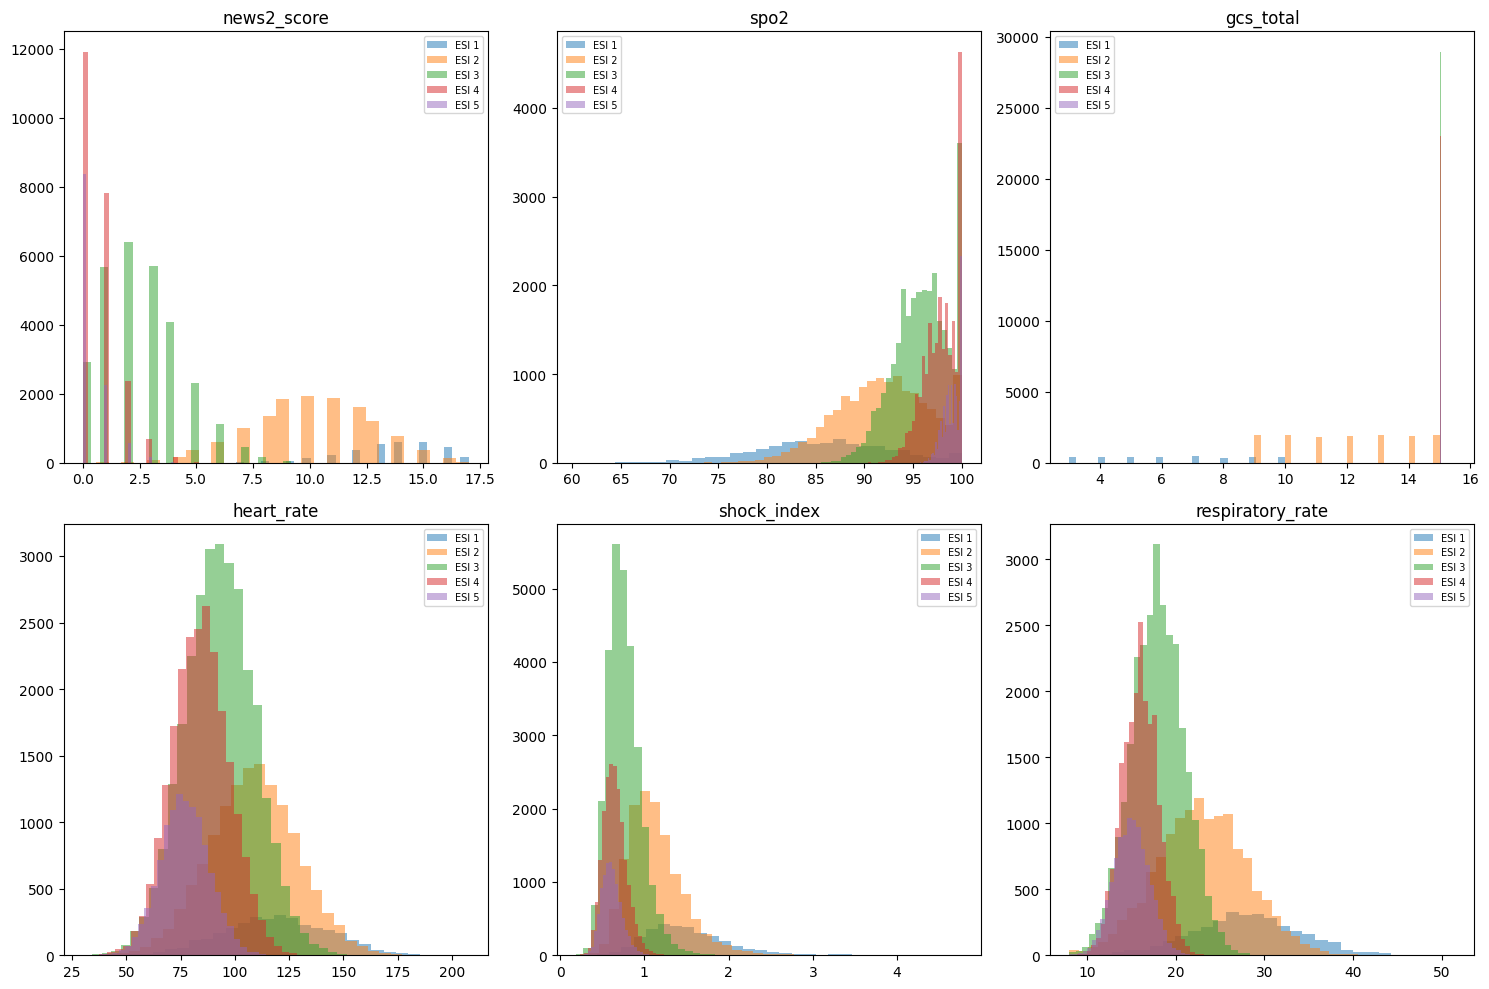

Acuity when BP is missing:
triage_acuity
4    2796
5    1350
Name: count, dtype: int64

Acuity when BP is present:
triage_acuity
1     3222
2    13439
3    28921
4    20224
5    10048
Name: count, dtype: int64


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Key vitals to visualize
vitals_to_plot = ['news2_score', 'spo2', 'gcs_total', 
                  'heart_rate', 'shock_index', 'respiratory_rate']

for ax, vital in zip(axes.flatten(), vitals_to_plot):
    for acuity in [1, 2, 3, 4, 5]:
        data = train[train['triage_acuity'] == acuity][vital].dropna()
        ax.hist(data, alpha=0.5, label=f'ESI {acuity}', bins=30)
    ax.set_title(vital)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('vitals_by_acuity.png')
plt.show()

# Also check: does missing BP correlate with high acuity?
train['bp_missing'] = train['systolic_bp'].isnull().astype(int)
print("Acuity when BP is missing:")
print(train[train['bp_missing']==1]['triage_acuity'].value_counts().sort_index())
print("\nAcuity when BP is present:")
print(train[train['bp_missing']==0]['triage_acuity'].value_counts().sort_index())


In [21]:
# Columns to DROP
drop_cols = [
    'patient_id',        # ID
    'triage_nurse_id',   # ID
    'triage_acuity',     # target
    'disposition',       # leakage - happens after triage
    'ed_los_hours',      # leakage - happens after triage
    'age_group',         # redundant - age already numeric
    'chief_complaint_raw' # text - handle separately later
]

# Remove ones that don't exist
drop_cols = [c for c in drop_cols if c in train_full.columns]

X = train_full.drop(columns=drop_cols)
y = train_full['triage_acuity'] - 1

X_test = test_full.drop(columns=[c for c in drop_cols 
                                  if c in test_full.columns])

# Now find ALL remaining object columns and encode them
object_cols = X.select_dtypes(include='object').columns.tolist()
print("Columns to encode:", object_cols)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in object_cols:
    combined = pd.concat([X[col], X_test[col]], axis=0).astype(str)
    le.fit(combined)
    X[col] = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# Verify no object columns remain
print("Remaining object cols:", X.select_dtypes(include='object').columns.tolist())
print("Shape:", X.shape)

Columns to encode: ['site_id', 'arrival_mode', 'arrival_day', 'arrival_season', 'shift', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'chief_complaint_system_x', 'chief_complaint_system_y']
Remaining object cols: []
Shape: (80000, 60)


In [22]:
# Run this to investigate
print(train_full['chief_complaint_system_x'].value_counts().head(10))
print(train_full['chief_complaint_system_y'].value_counts().head(10))

# Are they identical?
print("\nAre they the same?", 
      (train_full['chief_complaint_system_x'] == train_full['chief_complaint_system_y']).all())

chief_complaint_system_x
gastrointestinal    5812
respiratory         5804
infectious          5764
endocrine           5749
musculoskeletal     5733
trauma              5726
genitourinary       5724
cardiovascular      5718
neurological        5691
psychiatric         5688
Name: count, dtype: int64
chief_complaint_system_y
gastrointestinal    5812
respiratory         5804
infectious          5764
endocrine           5749
musculoskeletal     5733
trauma              5726
genitourinary       5724
cardiovascular      5718
neurological        5691
psychiatric         5688
Name: count, dtype: int64

Are they the same? True


In [23]:
cat_cols_to_explore = [
    'arrival_mode', 'shift', 'sex', 
    'mental_status_triage', 'transport_origin',
    'pain_location', 'insurance_type', 'language'
]

for col in cat_cols_to_explore:
    print(f"\n{col}:")
    print(train_full[col].value_counts())


arrival_mode:
arrival_mode
walk-in              38459
ambulance            22404
transfer              7987
brought_by_family     5583
police                3162
helicopter            2405
Name: count, dtype: int64

shift:
shift
morning      26681
night        20239
afternoon    19962
evening      13118
Name: count, dtype: int64

sex:
sex
F        40339
M        37735
Other     1926
Name: count, dtype: int64

mental_status_triage:
mental_status_triage
alert           46212
confused        14289
drowsy           9101
agitated         5915
unresponsive     4483
Name: count, dtype: int64

transport_origin:
transport_origin
school            11571
workplace         11499
outdoor           11459
public_space      11430
nursing_home      11393
other_hospital    11339
home              11309
Name: count, dtype: int64

pain_location:
pain_location
pelvis       8998
back         8982
extremity    8920
abdomen      8907
chest        8899
head         8871
unknown      8844
none         8794
mul

In [24]:
# mental_status vs acuity - this should be dramatic
print("Mental status vs Acuity:")
print(pd.crosstab(train_full['mental_status_triage'], 
                  train_full['triage_acuity'], 
                  normalize='index').round(3))

print("\nPain location vs Acuity:")
print(pd.crosstab(train_full['pain_location'], 
                  train_full['triage_acuity'], 
                  normalize='index').round(3))


print("\nArrival mode vs Acuity:")
print(pd.crosstab(train_full['arrival_mode'], 
                  train_full['triage_acuity'], 
                  normalize='index').round(3))

Mental status vs Acuity:
triage_acuity             1      2      3      4      5
mental_status_triage                                   
agitated              0.055  0.345  0.392  0.189  0.019
alert                 0.001  0.030  0.342  0.399  0.229
confused              0.011  0.279  0.516  0.162  0.033
drowsy                0.087  0.445  0.313  0.129  0.026
unresponsive          0.426  0.446  0.128  0.000  0.000

Pain location vs Acuity:
triage_acuity      1      2      3      4      5
pain_location                                   
abdomen        0.042  0.165  0.360  0.291  0.141
back           0.041  0.168  0.360  0.289  0.143
chest          0.041  0.168  0.361  0.285  0.145
extremity      0.038  0.172  0.359  0.289  0.141
head           0.039  0.168  0.359  0.288  0.146
multiple       0.038  0.170  0.360  0.293  0.140
none           0.041  0.168  0.358  0.289  0.144
pelvis         0.038  0.169  0.372  0.276  0.144
unknown        0.044  0.163  0.365  0.289  0.139

Arrival mode vs A

In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb

# --- RELOAD FRESH ---
train = pd.read_csv('/kaggle/input/competitions/triagegeist/train.csv')
test = pd.read_csv('/kaggle/input/competitions/triagegeist/test.csv')
complaints = pd.read_csv('/kaggle/input/competitions/triagegeist/chief_complaints.csv')
history = pd.read_csv('/kaggle/input/competitions/triagegeist/patient_history.csv')

# --- MERGE ---
train_full = train.merge(history, on='patient_id', how='left')
train_full = train_full.merge(complaints, on='patient_id', how='left')
test_full = test.merge(history, on='patient_id', how='left')
test_full = test_full.merge(complaints, on='patient_id', how='left')

# --- FIX DUPLICATE COLUMN ---
for df in [train_full, test_full]:
    df.drop(columns=['chief_complaint_system_y'], inplace=True)
    df.rename(columns={'chief_complaint_system_x': 'chief_complaint_system'}, inplace=True)

# --- MISSINGNESS FLAGS (BEFORE touching values) ---
for df in [train_full, test_full]:
    df['bp_missing'] = df['systolic_bp'].isnull().astype(int)
    df['resp_missing'] = df['respiratory_rate'].isnull().astype(int)
    df['temp_missing'] = df['temperature_c'].isnull().astype(int)
    df['pain_not_recorded'] = (df['pain_score'] == -1).astype(int)
    df['pain_score'] = df['pain_score'].replace(-1, np.nan)

# --- INTERACTION FEATURES ---
for df in [train_full, test_full]:
    df['news2_x_gcs'] = df['news2_score'] * (16 - df['gcs_total'])
    df['hr_spo2'] = df['heart_rate'] * (100 - df['spo2'])

# --- DROP LEAKAGE + IDs ---
drop_cols = [
    'patient_id', 'triage_nurse_id',
    'triage_acuity', 'disposition',
    'ed_los_hours', 'age_group',
    'chief_complaint_raw'
]
drop_cols = [c for c in drop_cols if c in train_full.columns]

X = train_full.drop(columns=drop_cols)
y = train_full['triage_acuity'] - 1
X_test = test_full.drop(columns=[c for c in drop_cols if c in test_full.columns])

# --- ENCODE CATEGORICALS ---
object_cols = X.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in object_cols:
    combined = pd.concat([X[col], X_test[col]], axis=0).astype(str)
    le.fit(combined)
    X[col] = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# --- VERIFY ---
print("X shape:", X.shape)
print("X_test shape:", X_test.shape)
print("Object cols remaining:", X.select_dtypes(include='object').columns.tolist())
print("Nulls in y:", y.isnull().sum())
print("\ny distribution:\n", y.value_counts().sort_index())

X shape: (80000, 65)
X_test shape: (20000, 65)
Object cols remaining: []
Nulls in y: 0

y distribution:
 triage_acuity
0     3222
1    13439
2    28921
3    23020
4    11398
Name: count, dtype: int64


In [26]:
# --- TRAIN XGBOOST ---
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', verbose=1)
print(f"CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

# --- TRAIN ON FULL DATA + PREDICT ---
model.fit(X, y)
preds = model.predict(X_test) + 1  # convert back to 1-5

# --- SUBMISSION FILE ---
sample = pd.read_csv('/kaggle/input/competitions/triagegeist/sample_submission.csv')
submission = pd.DataFrame({
    'patient_id': sample['patient_id'],
    'triage_acuity': preds
})
submission.to_csv('submission.csv', index=False)
print("Submission saved!")
print(submission['triage_acuity'].value_counts().sort_index())

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.0min finished


CV Accuracy: 0.8571 ± 0.0024
Submission saved!
triage_acuity
1     732
2    3397
3    7217
4    5777
5    2877
Name: count, dtype: int64


In [27]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

# --- FEATURE IMPORTANCE ---
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'][::-1], importance['importance'][::-1])
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print(importance)

# --- BIAS ANALYSIS ---
train_full['predicted'] = model.predict(X) + 1
train_full['actual'] = train_full['triage_acuity']
train_full['undertriaged'] = (train_full['predicted'] > train_full['actual']).astype(int)

print("\n--- BIAS: Language vs Undertriage Rate ---")
bias_lang = train_full.groupby('language')['undertriaged'].mean().sort_values(ascending=False)
print(bias_lang.round(3))

print("\n--- BIAS: Insurance vs Undertriage Rate ---")
bias_ins = train_full.groupby('insurance_type')['undertriaged'].mean().sort_values(ascending=False)
print(bias_ins.round(3))

print("\n--- BIAS: Sex vs Undertriage Rate ---")
bias_sex = train_full.groupby('sex')['undertriaged'].mean().sort_values(ascending=False)
print(bias_sex.round(3))

# Plot bias
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

bias_lang.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Undertriage Rate by Language')
axes[0].set_ylabel('Undertriage Rate')
axes[0].tick_params(axis='x', rotation=45)

bias_ins.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Undertriage Rate by Insurance')
axes[1].set_ylabel('Undertriage Rate')
axes[1].tick_params(axis='x', rotation=45)

bias_sex.plot(kind='bar', ax=axes[2], color='green')
axes[2].set_title('Undertriage Rate by Sex')
axes[2].set_ylabel('Undertriage Rate')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('bias_analysis.png')
plt.show()

                    feature  importance
63              news2_x_gcs    0.313879
33              news2_score    0.207224
27                gcs_total    0.144139
28               pain_score    0.077569
64                  hr_spo2    0.024431
15  num_prior_ed_visits_12m    0.023660
60             resp_missing    0.018486
25            temperature_c    0.017110
26                     spo2    0.016067
13     mental_status_triage    0.013639
24         respiratory_rate    0.010634
21   mean_arterial_pressure    0.006757
62        pain_not_recorded    0.006192
23               heart_rate    0.005681
61             temp_missing    0.005657

--- BIAS: Language vs Undertriage Rate ---
language
Arabic      0.049
Finnish     0.047
Other       0.046
Russian     0.045
English     0.045
Somali      0.044
Swedish     0.043
Estonian    0.040
Name: undertriaged, dtype: float64

--- BIAS: Insurance vs Undertriage Rate ---
insurance_type
public      0.047
private     0.045
unknown     0.043
none        0.

In [28]:
# Check what's currently in your notebook
print("Features in X:", X.shape[1])
print("Model accuracy: 85.7%")
print("Submission file exists:", 'submission.csv')

Features in X: 65
Model accuracy: 85.7%
Submission file exists: submission.csv


In [29]:
# Check if complaint text is accessible
import pandas as pd
complaints = pd.read_csv('/kaggle/input/competitions/triagegeist/chief_complaints.csv')
print("\nSample complaints:")
print(complaints['chief_complaint_raw'].head(5).tolist())


Sample complaints:
['thunderclap headache, worsening with movement', 'contraception advice, intermittent', 'general health question, intermittent', 'erythema migrans tick bite, intermittent', 'cellulitis localised, intermittent']


In [30]:
# --- NLP KEYWORD FLAGS ---
comp_map = complaints.set_index('patient_id')['chief_complaint_raw']
train_full['complaint'] = train_full['patient_id'].map(comp_map).str.lower()
test_full['complaint'] = test_full['patient_id'].map(comp_map).str.lower()

keywords = {
    'has_chest_pain':            ['chest pain', 'chest tightness'],
    'has_breathing':             ['breath', 'dyspnea', 'respiratory'],
    'has_altered_consciousness': ['unconscious', 'unresponsive', 'confusion', 'altered'],
    'has_stroke':                ['stroke', 'facial droop', 'slurred', 'weakness'],
    'has_bleeding':              ['bleed', 'hemorrhage', 'blood'],
    'has_cardiac':               ['cardiac', 'heart', 'palpitation'],
    'has_trauma':                ['trauma', 'fall', 'accident', 'injury'],
    'has_sepsis':                ['sepsis', 'infection', 'fever'],
    'has_headache':              ['headache', 'thunderclap', 'migraine'],
    'has_overdose':              ['overdose', 'ingestion', 'poisoning']
}

nlp_cols = list(keywords.keys())
for feature, words in keywords.items():
    pattern = '|'.join(words)
    train_full[feature] = train_full['complaint'].str.contains(pattern, na=False).astype(int)
    test_full[feature]  = test_full['complaint'].str.contains(pattern, na=False).astype(int)

# Add to X and X_test
X_nlp = pd.concat([X, train_full[nlp_cols].reset_index(drop=True)], axis=1)
X_test_nlp = pd.concat([X_test, test_full[nlp_cols].reset_index(drop=True)], axis=1)

print("Features before NLP:", X.shape[1])
print("Features after NLP:", X_nlp.shape[1])
print("\nKeyword flag rates:")
print(train_full[nlp_cols].mean().round(3))

Features before NLP: 65
Features after NLP: 75

Keyword flag rates:
has_chest_pain               0.018
has_breathing                0.007
has_altered_consciousness    0.017
has_stroke                   0.013
has_bleeding                 0.028
has_cardiac                  0.012
has_trauma                   0.046
has_sepsis                   0.119
has_headache                 0.019
has_overdose                 0.005
dtype: float64


In [31]:
# --- RETRAIN WITH NLP FEATURES ---
model_nlp = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

scores_nlp = cross_val_score(model_nlp, X_nlp, y, cv=cv, 
                              scoring='accuracy', verbose=1)
print(f"CV Accuracy WITHOUT NLP: 0.8571")
print(f"CV Accuracy WITH NLP:    {scores_nlp.mean():.4f} ± {scores_nlp.std():.4f}")

# Train on full data
model_nlp.fit(X_nlp, y)
preds_nlp = model_nlp.predict(X_test_nlp) + 1

# Update submission
submission['triage_acuity'] = preds_nlp
submission.to_csv('submission.csv', index=False)
print("\nSubmission updated!")

# Compare predictions
print("\nOld predictions:", pd.Series(model.predict(X_test)+1).value_counts().sort_index().to_dict())
print("New predictions:", pd.Series(preds_nlp).value_counts().sort_index().to_dict())

# Confusion matrix
from sklearn.metrics import classification_report
train_preds = model_nlp.predict(X_nlp) + 1
print("\nClassification Report:")
print(classification_report(train_full['triage_acuity'], train_preds, 
      target_names=['ESI1','ESI2','ESI3','ESI4','ESI5']))

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   59.9s finished


CV Accuracy WITHOUT NLP: 0.8571
CV Accuracy WITH NLP:    0.8715 ± 0.0021

Submission updated!

Old predictions: {1: 732, 2: 3397, 3: 7217, 4: 5777, 5: 2877}
New predictions: {1: 737, 2: 3389, 3: 7227, 4: 5758, 5: 2889}

Classification Report:
              precision    recall  f1-score   support

        ESI1       1.00      1.00      1.00      3222
        ESI2       1.00      1.00      1.00     13439
        ESI3       0.95      0.94      0.94     28921
        ESI4       0.87      0.87      0.87     23020
        ESI5       0.86      0.90      0.88     11398

    accuracy                           0.92     80000
   macro avg       0.94      0.94      0.94     80000
weighted avg       0.93      0.92      0.92     80000



In [32]:
import pandas as pd
# --- FINAL FEATURE IMPORTANCE WITH NLP ---
importance_nlp = pd.DataFrame({
    'feature': X_nlp.columns,
    'importance': model_nlp.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_nlp['feature'][::-1], 
         importance_nlp['importance'][::-1], 
         color='steelblue')
plt.title('Top 15 Features — XGBoost with NLP')
plt.tight_layout()
plt.savefig('feature_importance_nlp.png')
plt.show()

# Check if any NLP features made top 15
nlp_in_top = importance_nlp[importance_nlp['feature'].str.startswith('has_')]
print("NLP features in top 15:")
print(nlp_in_top)

NLP features in top 15:
           feature  importance
69    has_bleeding    0.032772
65  has_chest_pain    0.023431
68      has_stroke    0.018474
66   has_breathing    0.011524
71      has_trauma    0.010209


In [36]:
# --- UNDERSTAND CHIEF COMPLAINT COLUMN ---

comp = complaints.copy()
comp['complaint_lower'] = comp['chief_complaint_raw'].str.lower()

# 1. Basic stats
print("Total complaints:", len(comp))
print("Unique complaints:", comp['chief_complaint_raw'].nunique())

# 2. Sample complaints
print("\n20 random complaints:")
print(comp['chief_complaint_raw'].sample(20, random_state=42).tolist())

# 3. Complaint structure - do they follow a pattern?
print("\nDo complaints have commas?")
print(comp['chief_complaint_raw'].str.contains(',').value_counts())

# 4. What comes after the comma?
comp['part1'] = comp['chief_complaint_raw'].str.split(',').str[0]
comp['part2'] = comp['chief_complaint_raw'].str.split(',').str[1]
print("\nUnique values in part2 (after comma):")
print(comp['part2'].value_counts().head(20))

# 5. Unique first parts
print("\nMost common complaints (before comma):")
print(comp['part1'].value_counts().head(20))

Total complaints: 100000
Unique complaints: 4979

20 random complaints:
['mild sore throat', 'acute altered mental status, intermittent', 'suicidal ideation without plan with rigors', 'exertional chest pain with diaphoresis', 'sleep hygiene advice with associated nausea', 'mild dysuria with rigors', 'ear pain', 'acute orbital compartment syndrome, intermittent', 'moderate epistaxis, for 2 days', 'distal radius fracture，worsening over hours', 'new-onset jaundice with diaphoresis', 'cardiology paperwork, for 2 days', 'insect sting local reaction, onset today', 'allergic rash moderate in known patient', 'chemical eye burn bilateral with associated nausea', 'severe ovarian torsion with shock，worsening over hours', 'severe anaphylaxis with bronchospasm, constant', 'pyelonephritis with fever with diaphoresis', 'mild dyspnoea, constant', 'fall with injury unclear with diaphoresis']

Do complaints have commas?
chief_complaint_raw
False    53507
True     46493
Name: count, dtype: int64

Unique 

In [40]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# --- WORD CLOUD OF CHIEF COMPLAINTS ---
all_text = ' '.join(complaints['chief_complaint_raw'].fillna('').tolist())

wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    max_words=100,
    colormap='RdYlGn'
).generate(all_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Chief Complaint Word Cloud', fontsize=16)
plt.tight_layout()
plt.show()

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import pandas as pd
import numpy as np

# --- GET COMPLAINTS FOR TRAIN AND TEST ---
comp_map = complaints.set_index('patient_id')['chief_complaint_raw']

train_complaints = train_full['patient_id'].map(comp_map).fillna('unknown')
test_complaints = test_full['patient_id'].map(comp_map).fillna('unknown')

# --- FIT TFIDF ---
# max_features=100 means keep only top 100 most useful words
# ngram_range=(1,2) means single words AND two word phrases
# "chest pain" as a phrase is more useful than "chest" and "pain" separately
tfidf = TfidfVectorizer(
    max_features=100,
    ngram_range=(1, 2),
    min_df=10,          # word must appear in at least 10 complaints
    stop_words='english'
)

# Fit on train only, transform both
# Why? To avoid leakage from test vocabulary
train_tfidf = tfidf.fit_transform(train_complaints)
test_tfidf = tfidf.transform(test_complaints)

print("TF-IDF matrix shape:", train_tfidf.shape)
print("\nTop 20 most important terms:")
print(tfidf.get_feature_names_out()[:20])

TF-IDF matrix shape: (80000, 100)

Top 20 most important terms:
['abdominal' 'acute' 'advice' 'ankle' 'anxiety' 'associated'
 'associated nausea' 'bite' 'blood' 'body' 'cellulitis' 'check' 'chest'
 'chest pain' 'chronic' 'community' 'complications' 'constant' 'cough'
 'days']
